ATTENTION IS ALL YOU NEED
Paper link: https://arxiv.org/pdf/1706.03762

# Problem

- LSTM's and RNN's are sequential and do not allow for parallelization. This makes training very slow, especially for long sequences.

- In many tasks, long-range dependencies are important. RNN's and LSTM's struggle to capture these dependencies due to vanishing gradients (e.g., a verb and its object at the end of a long sentence). In CNN models, the number of operations required to relate signals from two different input positions grows with the distance between the positions. This makes it difficult to model long-range dependencies.

- The complexity of each layer of CNN is determined largely by the kernel size K, which is independent of the input length n. To increase the range of dependencies that can be captured, either K must be increased (which increases complexity) or more layers must be stacked (which increases the number of sequential operations required).

- Generalization sucks with RNN's and LSTM's, so you need a lot of data to train them well.

# Solution

Transformers can compute representations for all inputs and outputs in parallel, reducing training time.

Self attention connects all positions in a sequence directly with a constant number of operations, allowing for better modeling of long-range dependencies.

Sequence length (n) is smaller then the representation dimension (d). The complexity of self-attention is O(n^2 * d), while RNN's are O(n * d^2). Thus, for smaller sequences, self-attention is more efficient.

# Attention Head

- A head is a single attention mechanism that computes a weighted sum of values based on the similarity between queries and keys. 

- Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. Each head operates independently, and their outputs are concatenated and linearly transformed to produce the final output.


In [9]:
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

# Hyperparameters
batch_size = 32
block_size = 8
n_embd = 32
head_size = 4
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ENABLE NATIVE TENSOR CORES
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [10]:
with open('jfk-speeches.txt', encoding="utf-8") as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

# Character to integer mapping
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: [itos[i] for i in l]

data = torch.tensor(encode(text), dtype=torch.long)

n = int(len(data) * 0.8)
training_data = data[:n]
validation_data = data[n:]

In [11]:
def get_batch(split):
    d = training_data if split == 'train' else validation_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    # print(ix.shape)
    x = torch.stack([d[i: i + block_size] for i in ix])
    # print(x.shape)
    y = torch.stack([d[i + 1: i + block_size + 1] for i in ix])

    return x.to(device), y.to(device)

xb, yb = get_batch('train')

In [12]:
'''
Notice how in previous transformer, the positional encoding was defined using nn.Embedding

Problem: test on sequence lengths longer then training sequence lengths, will struggle to generalize

Instead of encoding the absolute position of each token, Transformer-XL encodes the relative position between tokens in the sequence. This means that attention scores 
depend on how far apart tokens are, rather than their absolute positions.

This means that the model learns how the relationship between two tokens changes based on their distance, not their absolute positions

For example, it might learn that "the token two positions before is important" rather than "the token at position 5 is important."

'''
class RelativePositionEmbedding(nn.Module):
    def __init__(self, max_seq_len, n_embd):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.n_embd = n_embd
        self.emb = nn.Parameter(torch.randn(n_embd, max_seq_len))
        self.emb.data.uniform_(-0.1, 0.1)
    
    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.emb[:, :seq_len]
        return x



In [13]:
'''
In encoder blocks, all tokens can talk with each other
in decoder blocks, use the infinity

Is there a sense of space? No, tokens don't know about their positions. you have to add that info in.

register_buffer registers a tensor that should be a part of state dict but not trained as parameter
'''

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))
    
    def forward(self, x):
        B, T, C = x.shape
        keys = self.key(x)
        queries = self.query(x)
        values = self.value(x)

        # attention_scores = queries * keys^T
        attention_scores = torch.matmul(queries, keys.transpose(1, 2))

        # divide since otherwise softmax will explode. Single token will dominate.
        attention_scores = attention_scores / (C ** 0.5)
        attention_scores = attention_scores.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        attention_probs = F.softmax(attention_scores, dim=-1)
        output = attention_probs @ values

        return output

class MultiHeadAttention(nn.Module):
    def __init__(self, head_size, num_heads):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.project = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]
        output = torch.cat(head_outputs, dim=-1)
        output = self.project(output)
        output = self.dropout(output)
        return output

class ModelBase(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd) # tokens -> dense vector representations
        self.transformer = Transformer()
        self.positional_embedding = nn.Embedding(block_size, n_embd) # positions idxs -> dense vectors
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.pre_ln = nn.LayerNorm(n_embd) # pre layer norm

        self.apply(self._init_weights)
    
    '''
    kaiming init
    '''
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, a=0, mode='fan_in', nonlinearity='relu')
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.ones_(module.weight)
            torch.nn.init.zeros_(module.bias)

    def forward(self, input, targets=None): # input is B * T (batch size * block size)
        '''
        Input IDs (32×8)
            ↓
        Token vectors (32×8×32)  +  Position vectors (8×32)
            ↓
        Combined embeddings (32×8×32)
            ↓
        Transformer attention & feed-forward (32×8×32)
            ↓
        Normalized (32×8×32)
            ↓
        Vocabulary predictions (32×8×65)
            ↓
        Loss calculation (1 number) ← compares to targets
        '''

        token_embeddings = self.token_embedding(input) # Shape: (B, T, C) = (32, 8, 32)
        positional_embeddings = self.positional_embedding(torch.arange(input.shape[1], device=device))
        embeddings = token_embeddings + positional_embeddings
        output = self.transformer(embeddings)
        output = self.pre_ln(output)

        logits = self.lm_head(output)

        if targets is None:
            return logits, None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

            return logits, loss

    def generate(self, idx, max_tokens):
        # Get rid of list append - work with tensors instead
        for _ in range(max_tokens):
            # crop idx to block_size tokens if longer
            idx_cond = idx[:, -block_size:]
            # get predictions
            logits, _ = self(idx_cond, None)
            # print("logits shape", logits.shape)
            # focus on last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # get probabilities
            probs = F.softmax(logits, dim=-1)
            # sample from distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append to sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx


class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(0.1)
        )
    
    def forward(self, x):
        return self.net(x)
    
'''
The final transformer architecture
'''
class Transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.layerNorm1 = nn.LayerNorm(n_embd)
        self.layerNorm2 = nn.LayerNorm(n_embd)
        self.attention = MultiHeadAttention(head_size, 8)
        self.feed_forward = FeedForward()

        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = x + self.dropout(self.attention(self.layerNorm1(x)))
        x = x + self.dropout(self.feed_forward(self.layerNorm2(x)))

        return x

In [14]:
@torch.no_grad()  # disable gradient tracking for efficiency
def estimate_loss():
    out = {}
    m.eval()  # set model to evaluation mode
    for split in ['train', 'val']:
        losses = torch.zeros(200)
        for k in range(200):
            X, Y = get_batch(split)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    m.train()  # set model back to training mode
    return out

def get_lr_lambda(warmup_steps=1000):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, 5000 - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return lr_lambda

m = ModelBase(vocab_size).to(device)
m = torch.compile(m)
optimizer = torch.optim.Adam(m.parameters(), lr=0.001, fused=True)

logits, loss = m(xb, yb)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda())


In [15]:
train_losses = []
val_losses = []
gradient_norms = []

num_epochs = 3

start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()

scaler = torch.cuda.amp.GradScaler()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    for i in range(5000):

        if i % 500 == 0:
            losses = estimate_loss()
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            print(f"step {i}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        
        xb, yb = get_batch('train')

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits, loss = m(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        total_norm = 0
        for p in m.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        gradient_norms.append(total_norm)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        if i % 100 == 0:
            print(f"step {i}: loss {loss.item()}")


end_event.record()

torch.cuda.synchronize()

total_time_ms = start_event.elapsed_time(end_event=end_event)
total_time_mn = total_time_ms / 1000 / 60
print(f"\nTotal training time: {total_time_mn:.2f} minutes")

/tmp/ipykernel_7329/408734403.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/3
step 0: train loss 5.3046, val loss 5.3120
step 0: loss 5.366265296936035
step 100: loss 4.640948295593262
step 200: loss 3.581070899963379
step 300: loss 3.209998607635498
step 400: loss 2.8330154418945312
step 500: train loss 2.6633, val loss 2.6798
step 500: loss 2.9495110511779785
step 600: loss 2.5995044708251953
step 700: loss 2.7889835834503174
step 800: loss 2.5518622398376465
step 900: loss 2.619791030883789
step 1000: train loss 2.3670, val loss 2.3877
step 1000: loss 2.5016212463378906
step 1100: loss 2.5997002124786377
step 1200: loss 2.2607693672180176
step 1300: loss 2.365507125854492
step 1400: loss 2.3358817100524902
step 1500: train loss 2.2187, val loss 2.2677
step 1500: loss 2.5401320457458496
step 1600: loss 2.3439269065856934
step 1700: loss 2.211496353149414
step 1800: loss 2.0791053771972656
step 1900: loss 2.2311959266662598
step 2000: train loss 2.1530, val loss 2.2014
step 2000: loss 2.3235416412353516
step 2100: loss 2.134974956512451
step 2200: los

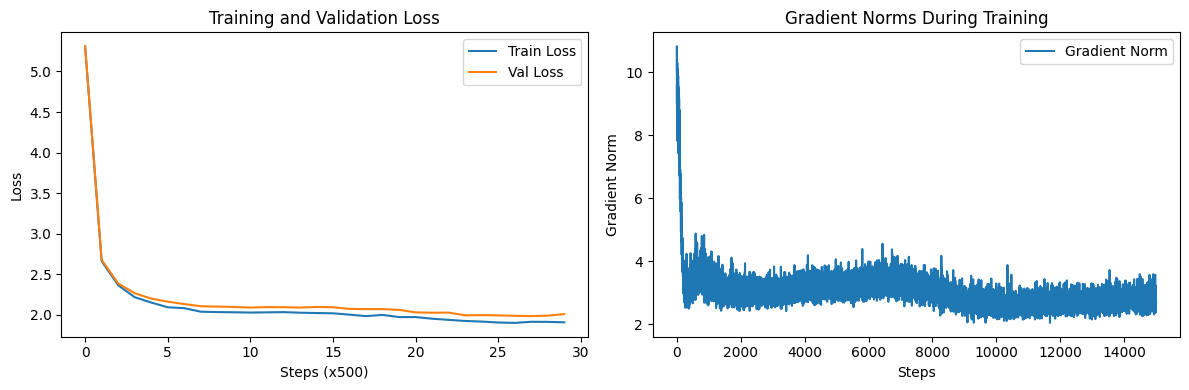

In [16]:
plt.figure(figsize=(12, 4))

# Plot losses
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Steps (x500)')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot gradient norms
plt.subplot(1, 2, 2)
plt.plot(gradient_norms, label='Gradient Norm')
plt.xlabel('Steps')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norms During Training')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Initialize context with a single token
context = torch.zeros((1, 1), dtype=torch.long, device=device)
# Generate 100 new tokens
generated_tokens = m.generate(context, max_tokens=500)[0].tolist()
# Convert tokens to text
generated_text = ''.join([itos[i] for i in generated_tokens])
print(generated_text)



But oprt and to the trationot of be if mond this trigor conts offrack of let, coreudlesight suwthidreited bee. Our cousic be had with sever in Macay--den to may the to to ere sthe natibliblid Aric, witho gilintss rewl unce somy of commf andconarticsitibe is coped peace trounnint, angefforics morentes the tinges rovery isercthemidedgever aree store aubritiling egren, oonut to beach lagy a a gred not thablillesy and teareosear fufrations have on all eng corly seve the pole-thoruce dust. Treing th


In [18]:
'''
smaller batch sizes lead to noisier gradients.

lr = 0.001: loss is 1.969
lr = 0.0001: loss is 2.09

added layer norm before attention: loss is 2.122
added weight initialization: loss is 1.96

added residual dropout on transformer class: loss is 1.88

Stabilize Training: preventin loss bouncing up and down.

batch size 64 and lr = 0.0001: loss is 2.085 but gradients seem to be more stable
added kaiming initialization: loss is 1.96

increased block size to 16: loss is 2.45
increased embd size to 64: loss is 2.30

'''

'\nsmaller batch sizes lead to noisier gradients.\n\nlr = 0.001: loss is 1.969\nlr = 0.0001: loss is 2.09\n\nadded layer norm before attention: loss is 2.122\nadded weight initialization: loss is 1.96\n\nadded residual dropout on transformer class: loss is 1.88\n\nStabilize Training: preventin loss bouncing up and down.\n\nbatch size 64 and lr = 0.0001: loss is 2.085 but gradients seem to be more stable\nadded kaiming initialization: loss is 1.96\n\nincreased block size to 16: loss is 2.45\nincreased embd size to 64: loss is 2.30\n\n'